In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from EFMM import FuzzyMinMaxNN

In [3]:
# In[86]:


fuzzy = FuzzyMinMaxNN(1,theta=0.3)    




In [4]:
# ## Dataset
# In[82]:


# X = [[0.2,0.2],[0.6,0.6],[0.5,0.5],[0.4,0.3],[0.8,0.1],[0.6,0.2],[0.7,0.6],[0.1,0.7],[0.3,0.9],[0.7,0.7],[0.9,0.9]]
# d = [[1],[2],[1],[2],[1],[1],[2],[2],[2],[1],[1]]

In [5]:
# In[87]:


# X = [[0.4,0.3],[0.6,0.25],[0.7,0.6], [0.9, 0.65], [.5,.29], [.65,.5]]
# d = [[1],[1],[0],[0],[0], [0]]
# print(X)
# print(d)

In [6]:
X = [[0.1,0.1],[0.2,0.3],[0.2,0.4], [0.35, 0.5], [.45,.5], [.7,.7], [.5,.6], [.62,.8], [.7,.1], [.99,.4], [.8,.15]
                , [.9,.3], [.8,.8], [.9,.9], [.85,.65], [.99,.85]]
d = [[1],[1],[0],[0],[1],[1],[0],[0],[1],[1],[0],[0],[1],[1],[0],[0],]

# X = [[0.1,0.1],[0.2,0.3],[0.2,0.4], [0.35, 0.5], [.45,.5], [.7,.7], [.5,.6], [.62,.8], [.7,.1], [.99,.4]] 

# X_test = [[.8,.15], [.9,.3], [.8,.8], [.9,.9], [.85,.65], [.99,.85]]

# d = [[1],[1],[0],[0],[1],[1],[0],[0],[1],[1]]
# d_test =[[0],[0],[1],[1],[0],[0]]

print(X)
# print(X_test)
print(d)
# print(d_test)



[[0.1, 0.1], [0.2, 0.3], [0.2, 0.4], [0.35, 0.5], [0.45, 0.5], [0.7, 0.7], [0.5, 0.6], [0.62, 0.8], [0.7, 0.1], [0.99, 0.4], [0.8, 0.15], [0.9, 0.3], [0.8, 0.8], [0.9, 0.9], [0.85, 0.65], [0.99, 0.85]]
[[1], [1], [0], [0], [1], [1], [0], [0], [1], [1], [0], [0], [1], [1], [0], [0]]


In [7]:
# In[88]:


fuzzy.train(X,d,1)



epoch : 1
input pattern :  [0.1, 0.1] [1]
Hyperbox : [0.1, 0.1] , [0.1, 0.1] 
input pattern :  [0.2, 0.3] [1]
Hyperbox : [0.1, 0.1] , [0.1, 0.1] 
Expanded Hyperbox :  [0.1, 0.1] [0.2, 0.3]
input pattern :  [0.2, 0.4] [0]
Hyperbox : [0.2, 0.4] , [0.2, 0.4] 
input pattern :  [0.35, 0.5] [0]
Hyperbox : [0.2, 0.4] , [0.2, 0.4] 
Expanded Hyperbox :  [0.2, 0.4] [0.35, 0.5]
input pattern :  [0.45, 0.5] [1]
Hyperbox : [0.2, 0.4] , [0.35, 0.5] 
Expanded Hyperbox :  [0.2, 0.4] [0.45, 0.5]
input pattern :  [0.7, 0.7] [1]
Hyperbox : [0.7, 0.7] , [0.7, 0.7] 
input pattern :  [0.5, 0.6] [0]
Hyperbox : [0.2, 0.4] , [0.45, 0.5] 
Expanded Hyperbox :  [0.2, 0.4] [0.5, 0.6]
input pattern :  [0.62, 0.8] [0]
Hyperbox : [0.62, 0.8] , [0.62, 0.8] 
input pattern :  [0.7, 0.1] [1]
Hyperbox : [0.7, 0.1] , [0.7, 0.1] 
input pattern :  [0.99, 0.4] [1]
Hyperbox : [0.7, 0.7] , [0.7, 0.7] 
Expanded Hyperbox :  [0.7, 0.4] [0.99, 0.7]
Contracted hyperbox 1 :  [0.2, 0.4] [0.5, 0.6]
Contracted hyperbox 2 :  [0.7, 0.6] [

In [8]:
len(fuzzy.V),len(fuzzy.W)

print("\n", fuzzy.V)


 [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]


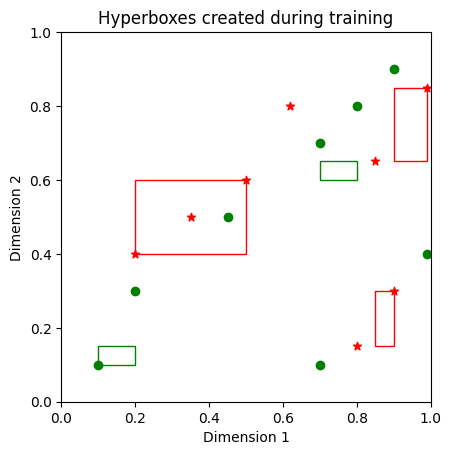

In [9]:
# ### Visualization of HyperBoxes

# In[90]:


import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_box(ax,a,b,color):
    width = abs(a[0] - b[0])
    height = abs(a[1] - b[1])
    ax.add_patch(patches.Rectangle(a, width, height, fill=False,edgecolor=color))

"""
    plot dataset
"""
fig1 = plt.figure()
ax = fig1.add_subplot(111, aspect='equal',alpha=0.7)

        
"""
    plot Hyperboxes
"""
for i in range(len(fuzzy.V)):
    if fuzzy.hyperbox_class[i]==[1]:
        draw_box(ax,fuzzy.V[i],fuzzy.W[i],color='g')
    else:
        draw_box(ax,fuzzy.V[i],fuzzy.W[i],color='r')
    
for i in range(len(X)):
    if d[i] == [1]:
        ax.scatter(X[i][0],X[i][1] , marker='o', c='g')
    else:
        ax.scatter(X[i][0],X[i][1] , marker='*', c='r')
    
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Hyperboxes created during training')
plt.xlim([0,1])
plt.ylim([0,1])
#plt.legend(('class 1','class 2'))
plt.show()


In [10]:

def get_class(x):
        mylist = []
        for i in range(len(fuzzy.V)):
            mylist.append([fuzzy.fuzzy_membership(x,fuzzy.V[i],fuzzy.W[i])])
        result = np.multiply(mylist,fuzzy.U)
        mylist=[]
        for i in range(fuzzy.clasess):
            mylist.append(max(result[:,i]))
            
        #print(mylist)
        #print(mylist.index(max(mylist))+1,max(mylist))
        #print('pattern belongs to class {} with fuzzy membership : {}'.format(mylist.index(max(mylist))+1,max(mylist)))
        return [mylist.index(max(mylist))+1]


def score(train,train_labels):
    counter=0
    wronge=0
    for i in range(len(train)):
        if get_class(train[i]) == train_labels[i] :
            counter+=1
        else:
            wronge+=1
            
    print('No of misclassification : {}'.format(wronge))
    return (counter/len(train_labels))*100

In [11]:
print('Accuracy (train) : {} %'.format(score(X,d)))

No of misclassification : 12
Accuracy (train) : 25.0 %


In [12]:
# print('Accuracy (test) : {} %'.format(score(X_test,d_test)))

In [17]:
# ### Testing of pattern 
# In[89]:

Y = [[.3,.2], [.5,.29], [.45,.26], [.65,.5], [.75,.62], [.95,.7]]



# def class_omega(test):

#     return np.argmax(test) + 1

def predict(x):
    mylist = []
    print("\n this is V", fuzzy.V)
    print("\n This is len of V", len(fuzzy.V))
    for i in range(len(fuzzy.V)):
        mylist.append([fuzzy.fuzzy_membership(x,fuzzy.V[i],fuzzy.W[i])])
        
    result = np.multiply(mylist,fuzzy.U)
    test = []
    for i in range(fuzzy.clasess):
        # print('pattern {} belongs to class {} with fuzzy membership value : {}'.format(x,i+1,max(result[:,i])))
        # print(max(result[:,i]))
        test.append((max(result[:,i])))
        # print(test)
    
    class_omega = np.argmax(test) + 1
    return class_omega


test = []
for x in Y:
    prediction = predict(x)
    test.append(prediction)
    print('='*80)

print(" This is test", test)



 this is V [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]

 This is len of V 7

 this is V [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]

 This is len of V 7

 this is V [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]

 This is len of V 7

 this is V [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]

 This is len of V 7

 this is V [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]

 This is len of V 7

 this is V [[0.1, 0.1], [0.2, 0.4], [0.7, 0.6], [0.9, 0.65], [0.7, 0.1], [0.85, 0.15], [0.9, 0.9]]

 This is len of V 7
 This is test [1, 2, 2, 1, 1, 2]


In [ ]:
import random
import numpy as np
import pandas as pd
from itertools import count
from datetime import datetime
import time
from matplotlib.animation import FuncAnimation

import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('fivethirtyeight')

label = []
x_label = []
pred_x = 0
def animate(i):
        ful = []
        global pred_x
        data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\data.csv')

        x = data['x_value']
        y1 = data['total_1']
        y2 = data['total_2']


        len1 = y1.size
        len2 = y2.size


        yint1 = y1[len1-1]
        yint2 = y2[len2-1]

        ful.append(y1[len1-1])
        ful.append(y2[len2-1])

        
        prediction = predict(ful)
        

        label.append(prediction)
        x_label.append(pred_x)
      

        pred_x = pred_x + 1

        data_y = pd.Series(label)

        data_x = pd.Series(x_label)



        plt.cla()
        plt.plot(data_x, data_y, label='Channel 1')

        plt.legend(loc='upper left')
        plt.tight_layout()

ani = FuncAnimation(plt.gcf(), animate, interval = 500)

plt.tight_layout()
plt.show()


c:\Users\dema2\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\animation.py:887: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you have outputted the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


<Figure size 640x480 with 0 Axes>